# 3 домашка по биоинформатике. 4 задание

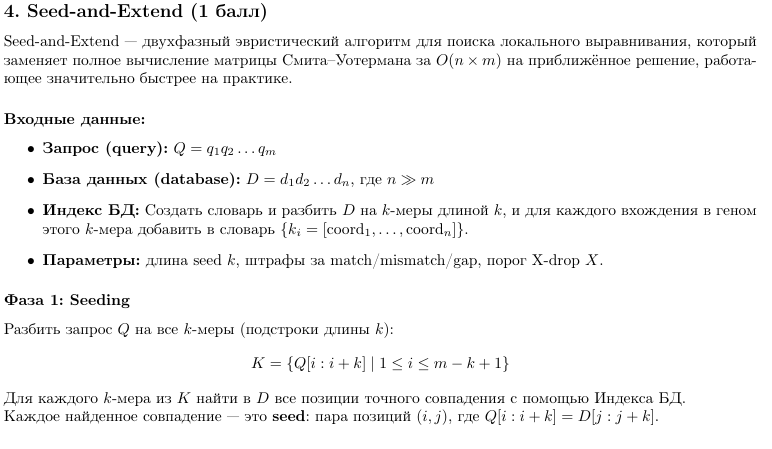

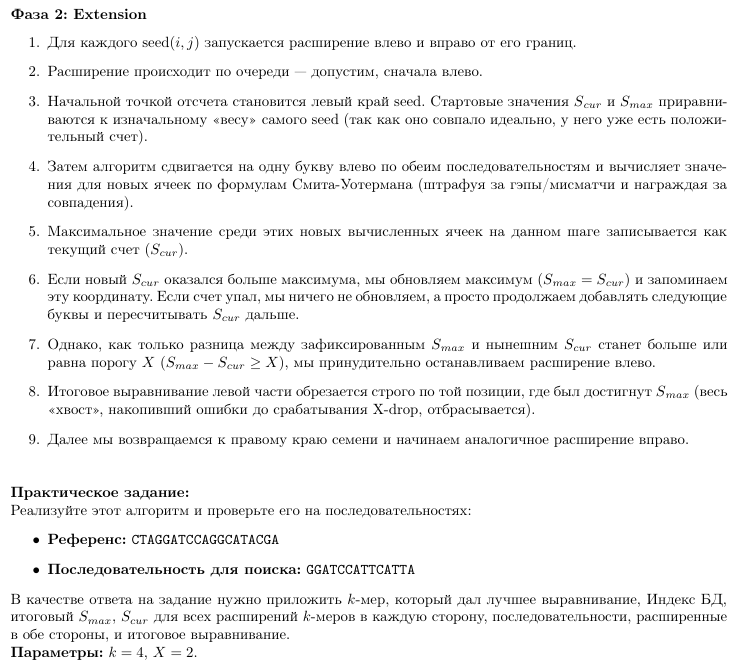

In [1]:
match = 3
mismatch = -3
gap = -2
k = 4
X = 2

reference = "CTAGGATCCAGGCATACGA"
query = "GGATCCATTCATTA"

In [2]:
db_index = {} #это все к-меры со своими индексами в референсе
for i in range(len(reference) - k + 1):
    kmer = reference[i:i+k]
    if kmer not in db_index:
        db_index[kmer] = []
    db_index[kmer].append(i)

In [3]:
db_index

{'CTAG': [0],
 'TAGG': [1],
 'AGGA': [2],
 'GGAT': [3],
 'GATC': [4],
 'ATCC': [5],
 'TCCA': [6],
 'CCAG': [7],
 'CAGG': [8],
 'AGGC': [9],
 'GGCA': [10],
 'GCAT': [11],
 'CATA': [12],
 'ATAC': [13],
 'TACG': [14],
 'ACGA': [15]}

In [4]:
seeds = [] #здесь тройки (к-мер, индекс в query, индекс в reference)
for i in range(len(query) - k + 1):
    kmer = query[i:i+k]
    if kmer in db_index:
        for j in db_index[kmer]:
            seeds.append((kmer, i, j))

for kmer, qi, ri in seeds:
    print(f"  '{kmer}'  query[{qi}]  ref[{ri}]")

  'GGAT'  query[0]  ref[3]
  'GATC'  query[1]  ref[4]
  'ATCC'  query[2]  ref[5]
  'TCCA'  query[3]  ref[6]


In [5]:
def extend(q_start, r_start, step):
    scur, smax, best_steps = 0, 0, 0
    history = []
    q, r, steps = q_start, r_start, 0

    while 0 <= q < len(query) and 0 <= r < len(reference):
        scur += match if query[q]==reference[r] else mismatch
        steps += 1
        history.append((steps, query[q], reference[r], scur))
        if scur > smax:
            smax  = scur
            best_steps = steps
        if smax - scur >= X:
            break
        q += step
        r += step

    return smax, best_steps, history

In [6]:
results = []
for kmer, q_seed, r_seed in seeds:
  seed_score = k*match
  left_score,  left_steps,  left_history  = extend(q_seed - 1, r_seed - 1, -1)
  right_score, right_steps, right_history = extend(q_seed + k, r_seed + k, +1)
  total = seed_score + left_score + right_score

  results.append({"kmer":    kmer,
                  "q_seed":  q_seed,
                  "r_seed":  r_seed,
                  "total":   total,
                  "aq":      query    [q_seed - left_steps  : q_seed + k + right_steps],
                  "ar":      reference[r_seed - left_steps  : r_seed + k + right_steps],
                  "left":    (left_score,  left_history),
                  "right":   (right_score, right_history)})

for res in results:
  print()
  print(f"к-мер '{res['kmer']}'  query[{res['q_seed']}]  reference[{res['r_seed']}]  seed_score={k * match}")
  print(f"  влево  (шаг, q, r, S_cur): {res['left'][1]}")
  print(f"  вправо (шаг, q, r, S_cur): {res['right'][1]}")
  print(f"  S_max = {res['total']}")
  print(f"  query: {res['aq']}")
  print(f"  reference:   {res['ar']}")


к-мер 'GGAT'  query[0]  reference[3]  seed_score=12
  влево  (шаг, q, r, S_cur): []
  вправо (шаг, q, r, S_cur): [(1, 'C', 'C', 3), (2, 'C', 'C', 6), (3, 'A', 'A', 9), (4, 'T', 'G', 6)]
  S_max = 21
  query: GGATCCA
  reference:   GGATCCA

к-мер 'GATC'  query[1]  reference[4]  seed_score=12
  влево  (шаг, q, r, S_cur): [(1, 'G', 'G', 3)]
  вправо (шаг, q, r, S_cur): [(1, 'C', 'C', 3), (2, 'A', 'A', 6), (3, 'T', 'G', 3)]
  S_max = 21
  query: GGATCCA
  reference:   GGATCCA

к-мер 'ATCC'  query[2]  reference[5]  seed_score=12
  влево  (шаг, q, r, S_cur): [(1, 'G', 'G', 3), (2, 'G', 'G', 6)]
  вправо (шаг, q, r, S_cur): [(1, 'A', 'A', 3), (2, 'T', 'G', 0)]
  S_max = 21
  query: GGATCCA
  reference:   GGATCCA

к-мер 'TCCA'  query[3]  reference[6]  seed_score=12
  влево  (шаг, q, r, S_cur): [(1, 'A', 'A', 3), (2, 'G', 'G', 6), (3, 'G', 'G', 9)]
  вправо (шаг, q, r, S_cur): [(1, 'T', 'G', -3)]
  S_max = 21
  query: GGATCCA
  reference:   GGATCCA


In [7]:
b = max(results, key=lambda r: r["total"])

print(f"Лучший к-мер: '{b['kmer']}' - на позициях query[{b['q_seed']}] и reference[{b['r_seed']}]")
print(f"S_max = {b['total']}")
print(f"query: {b['aq']}")
print(f"ref:   {b['ar']}")

Лучший к-мер: 'GGAT' - на позициях query[0] и reference[3]
S_max = 21
query: GGATCCA
ref:   GGATCCA


In [8]:
q_start = b["q_seed"] - left_steps
r_start = b["r_seed"] - left_steps
shift = r_start - q_start


In [9]:
if shift > 0:
    query = "-" * shift + query
elif shift < 0:
    reference = "-" * (-shift) + reference

L = max(len(reference), len(query))
if len(reference) < L:
    reference = reference + "-" * (L - len(reference))
if len(query) < L:
    query = query + "-" * (L - len(query))

print("Полное выравнивание")
print("reference:", reference)
print("query:    ", query)

Полное выравнивание
reference: CTAGGATCCAGGCATACGA
query:     ---GGATCCATTCATTA--
